# What is your song* audio aura?

Credit to https://www.kaggle.com/datasets/jarredpriester/taylor-swift-spotify-dataset for providing a comprehensive dataset for Taylor Swift songs from Spotify!

For context, in my previous company we used to have a weekly tech sharing session. We are bunch of Android engineers, so I tried to think- as always what excited me the most? Okay, my current papo is Spotify Wrapped, I can not remember exactly what year is it but, Spotify ***really really provide US*** (well, me defo very excited atm) a Spotify Audio Aura. It was really captivating. I did some digging and found the behind-the-scene that is more exciting! glad it is well-documented so it is easier for me to learn more about it in tech side 👀

well, I decided to make a duplicate, I think I use KMeans that time (too) lol. sadly, the project is in my company's account github (which already removed because I resigned) so, this project its pretty much a tweak from that version.

Another disclaimer, this is for Taylor Swift songs only! Dataset last updated about 2 years ago. The newest album is 2024 The Tortured Department. Feel free to test with Tay's new release song such as my favourite: ***Ruin the Friendship*** 😜

Goal: cluster Taylor Swift songs by audio features to assign each song an Audio Aura!

> Hope everyone will enjoy with this (*quite*) personal project!

References:
https://newsroom.spotify.com/2021-12-01/learn-more-about-the-audio-aura-in-your-spotify-2021-wrapped-with-aura-reader-mystic-michaela/

https://engineering.atspotify.com/2021/12/the-audio-aura-story-mystical-to-mathematical

In [571]:
import numpy as np
import pandas as pd

df = pd.read_csv('data/taylor_swift_spotify.csv')
df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Fortnight (feat. Post Malone),THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,2024-04-19,1,6dODwocEuGzHAavXqTbwHv,spotify:track:6dODwocEuGzHAavXqTbwHv,0.5020,0.504,0.386,0.000015,0.0961,-10.976,0.0308,192.004,0.281,82,228965
1,1,The Tortured Poets Department,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,2024-04-19,2,4PdLaGZubp4lghChqp8erB,spotify:track:4PdLaGZubp4lghChqp8erB,0.0483,0.604,0.428,0.000000,0.1260,-8.441,0.0255,110.259,0.292,79,293048
2,2,My Boy Only Breaks His Favorite Toys,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,2024-04-19,3,7uGYWMwRy24dm7RUDDhUlD,spotify:track:7uGYWMwRy24dm7RUDDhUlD,0.1370,0.596,0.563,0.000000,0.3020,-7.362,0.0269,97.073,0.481,80,203801
3,3,Down Bad,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,2024-04-19,4,1kbEbBdEgQdQeLXCJh28pJ,spotify:track:1kbEbBdEgQdQeLXCJh28pJ,0.5600,0.541,0.366,0.000001,0.0946,-10.412,0.0748,159.707,0.168,82,261228
4,4,"So Long, London",THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,2024-04-19,5,7wAkQFShJ27V8362MqevQr,spotify:track:7wAkQFShJ27V8362MqevQr,0.7300,0.423,0.533,0.002640,0.0816,-11.388,0.3220,160.218,0.248,80,262974


In [572]:
summary_stats = df.describe().T
summary_stats['CV (%)'] = (summary_stats['std'] / summary_stats['mean']) * 100  #covariance
summary_stats

,count,mean,std,min,25%,50%,75%,max,CV (%)
Unnamed: 0,582.0,290.500000,168.153204,0.000000,145.250000,290.500000,435.750000,581.000,57.884063
track_number,582.0,11.422680,8.042060,1.000000,5.000000,10.000000,15.000000,46.000,70.404319
acousticness,582.0,0.333185,0.327171,0.000182,0.037325,0.184500,0.660000,0.971,98.195169
danceability,582.0,0.580804,0.114553,0.175000,0.515000,0.593500,0.653000,0.897,19.723236
energy,582.0,0.565832,0.191102,0.118000,0.418000,0.571000,0.719000,0.948,33.773596
instrumentalness,582.0,0.003393,0.027821,0.000000,0.000000,0.000002,0.000058,0.333,819.881970
liveness,582.0,0.161130,0.136563,0.033500,0.096525,0.114500,0.161000,0.931,84.753171
loudness,582.0,-7.661986,2.904653,-17.932000,-9.400750,-7.352500,-5.494750,-1.927,-37.909924
speechiness,582.0,0.056475,0.070859,0.023100,0.030300,0.037600,0.054800,0.912,125.469640
tempo,582.0,122.398954,30.408485,68.097000,96.888000,119.054500,143.937250,208.918,24.843746


In [573]:
"""
Drop unnecessary columns. Check null, put median. Normalise/scale if there is weird number. Check outlier.
duration_ms,popularity,tempo need to be scale 0-1
"""

df = df.drop(columns=['Unnamed: 0', 'release_date', 'track_number', 'id', 'uri', 'loudness'])
df.head()

,name,album,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,popularity,duration_ms
0,Fortnight (feat. Post Malone),THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.5020,0.504,0.386,0.000015,0.0961,0.0308,192.004,0.281,82,228965
1,The Tortured Poets Department,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.0483,0.604,0.428,0.000000,0.1260,0.0255,110.259,0.292,79,293048
2,My Boy Only Breaks His Favorite Toys,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.1370,0.596,0.563,0.000000,0.3020,0.0269,97.073,0.481,80,203801
3,Down Bad,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.5600,0.541,0.366,0.000001,0.0946,0.0748,159.707,0.168,82,261228
4,"So Long, London",THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.7300,0.423,0.533,0.002640,0.0816,0.3220,160.218,0.248,80,262974


In [574]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              582 non-null    str    
 1   album             582 non-null    str    
 2   acousticness      582 non-null    float64
 3   danceability      582 non-null    float64
 4   energy            582 non-null    float64
 5   instrumentalness  582 non-null    float64
 6   liveness          582 non-null    float64
 7   speechiness       582 non-null    float64
 8   tempo             582 non-null    float64
 9   valence           582 non-null    float64
 10  popularity        582 non-null    int64  
 11  duration_ms       582 non-null    int64  
dtypes: float64(8), int64(2), str(2)
memory usage: 82.9 KB


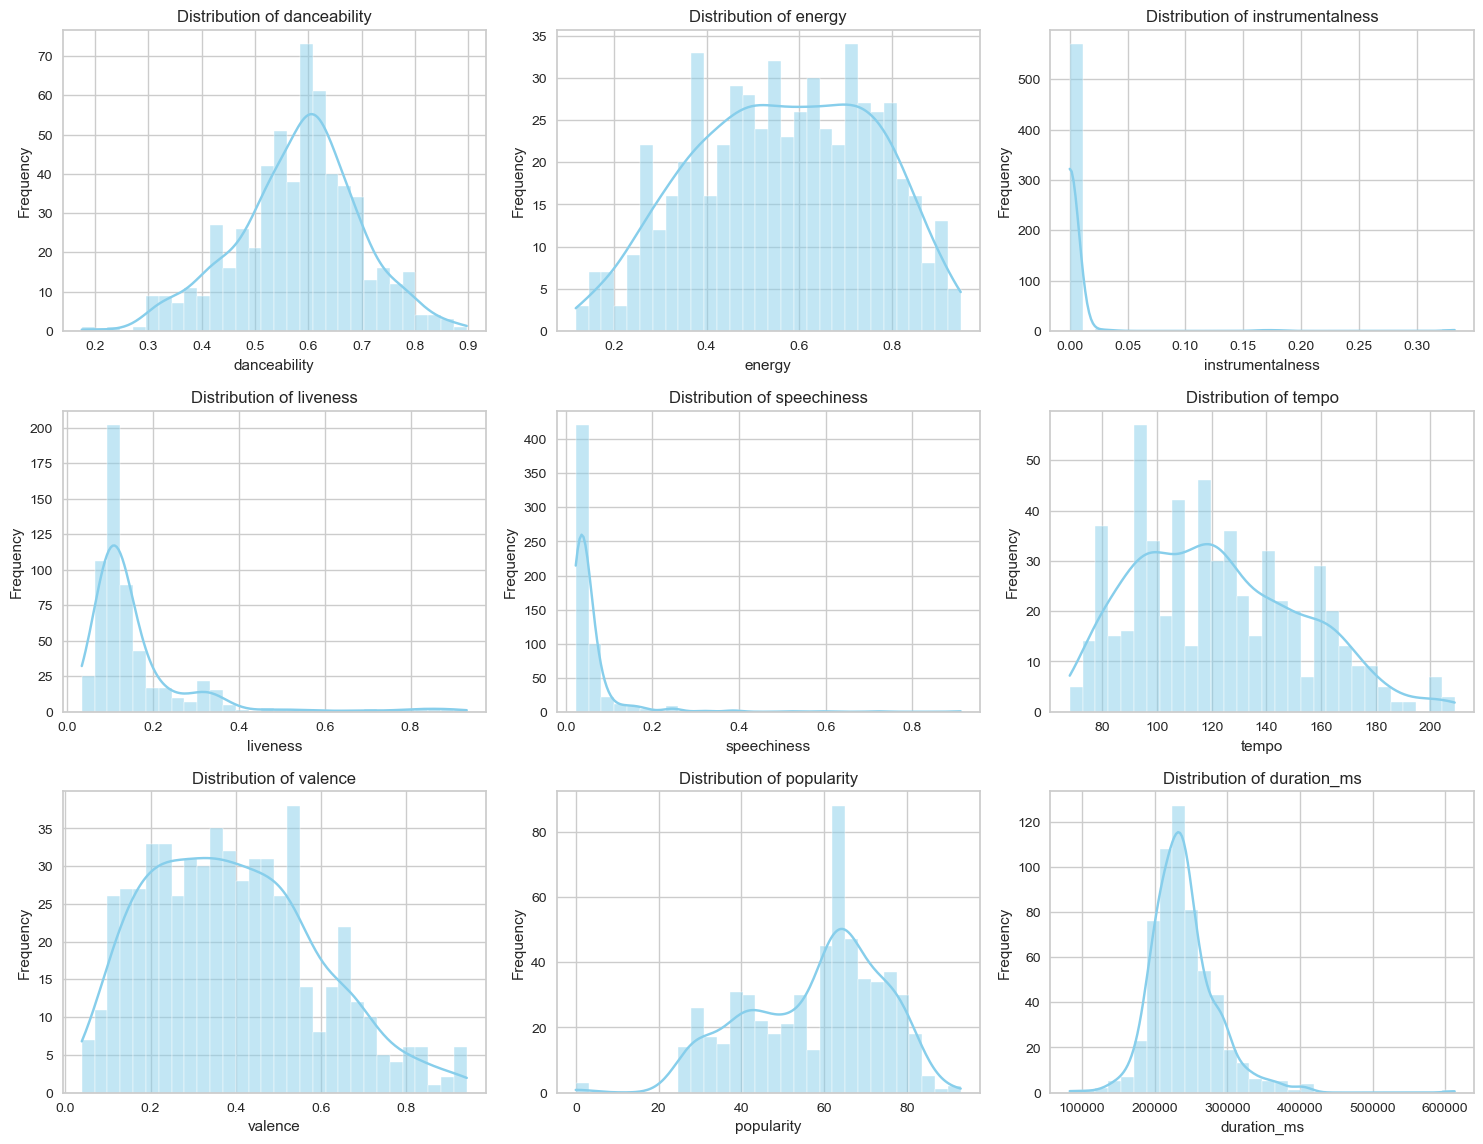

In [575]:
#plot each features [acousticness, dancebility,energy,instrumentalness,liveness,loudness,speechiness, tempo, valence, popularity, duration_ms]

import matplotlib.pyplot as plt
import seaborn as sns

features = ['danceability', 'energy', 'instrumentalness',
            'liveness', 'speechiness', 'tempo', 'valence',
            'popularity', 'duration_ms']

plt.figure(figsize=(15, 15))

for i, feature in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [576]:
df.describe()

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,popularity,duration_ms
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,0.333185,0.580804,0.565832,0.003393,0.161130,0.056475,122.398954,0.391000,57.857388,240011.189003
std,0.327171,0.114553,0.191102,0.027821,0.136563,0.070859,30.408485,0.195829,16.152520,45928.954305
min,0.000182,0.175000,0.118000,0.000000,0.033500,0.023100,68.097000,0.038400,0.000000,83253.000000
25%,0.037325,0.515000,0.418000,0.000000,0.096525,0.030300,96.888000,0.230000,45.000000,211823.000000
50%,0.184500,0.593500,0.571000,0.000002,0.114500,0.037600,119.054500,0.374000,62.000000,235433.000000
75%,0.660000,0.653000,0.719000,0.000058,0.161000,0.054800,143.937250,0.522500,70.000000,260819.500000
max,0.971000,0.897000,0.948000,0.333000,0.931000,0.912000,208.918000,0.943000,93.000000,613026.000000


In [577]:
df.isnull().sum()

name                0
album               0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

# Exploring Tay's songs~
I will drop ***[liveness, instrumentalness, speechiness]*** why?
1. liveness, prolly would get confused with her live or non-live recording which wont affect the colour
2. instrumentalness, basically she is a **SINGER** it's self-explanotary lol. same goes with speechniess, she is definitely singing so I think these columns is not reliable!

In [578]:
df = df.drop(columns=['liveness', 'instrumentalness',
                      'speechiness'])  #look at the distribution and co-efficent of variance, we should just drop it~~
df.head()

,name,album,acousticness,danceability,energy,tempo,valence,popularity,duration_ms
0,Fortnight (feat. Post Malone),THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.5020,0.504,0.386,192.004,0.281,82,228965
1,The Tortured Poets Department,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.0483,0.604,0.428,110.259,0.292,79,293048
2,My Boy Only Breaks His Favorite Toys,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.1370,0.596,0.563,97.073,0.481,80,203801
3,Down Bad,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.5600,0.541,0.366,159.707,0.168,82,261228
4,"So Long, London",THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.7300,0.423,0.533,160.218,0.248,80,262974


In [579]:

"""
Feature engineering!
tempo-popularity-duration_ms need to be normalize!
loudness is negative
DEPRECATED USE REUSABLE FUNCTION

"""
# scaler = MinMaxScaler()
# cols = ['popularity',
#         'duration_ms']  # I initially put tempo here but in iteration 3 I decided to apply binning for tempo!
# df[cols] = scaler.fit_transform(df[cols])
# 
# df.head()

'\nFeature engineering!\ntempo-popularity-duration_ms need to be normalize!\nloudness is negative\nDEPRECATED USE REUSABLE FUNCTION\n\n'

# This process is iterative! This is not available during phase 1, because I want to compare the silhoutte score!


In [580]:
"""
DEPRECATED USE REUSABLE FUNCTION
Feature engineering! pt. 2 trying to find correlation between variables
"""

# score based on mood???
# df['dancy_score'] = df['danceability'] * df['energy'] * df['loudness']
# df['happy_score'] = df['energy'] * df['valence'] 
# df['poet_calm_score'] = (1 - df['energy']) * (1- df['valence'] )

# binning tempo, based on Google!
# conditions = [
#     (df['tempo'] <= 90),
#     (df['tempo'] > 90) & (df['tempo'] <= 110),
#     (df['tempo'] > 110)
# ]
# tempo_type = ['Slow', 'Medium', 'Fast']
# df['tempo_cat'] = np.select(conditions, tempo_type, default='Unknown')
# df = df.drop('tempo', axis=1)
# 
# oe = OrdinalEncoder(categories=[['Slow', 'Medium', 'Fast']])
# df['tempo_cat'] = oe.fit_transform(df[['tempo_cat']])
# df['tempo_cat'] = scaler.fit_transform(df[['tempo_cat']])



'\nDEPRECATED USE REUSABLE FUNCTION\nFeature engineering! pt. 2 trying to find correlation between variables\n'

In [581]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler


def scale_data(dt):
    dt = dt.copy()
    scaler = MinMaxScaler()
    cols = ['popularity',
            'duration_ms']  # I initially put tempo here but in iteration 3 I decided to apply binning for tempo!
    dt[cols] = scaler.fit_transform(dt[cols])

    conditions = [
        (dt['tempo'] <= 90),
        (dt['tempo'] > 90) & (dt['tempo'] <= 110),
        (dt['tempo'] > 110)
    ]

    tempo_type = ['Slow', 'Medium', 'Fast']
    dt['tempo_cat'] = np.select(conditions, tempo_type, default='Medium')
    dt = dt.drop('tempo', axis=1)

    oe = OrdinalEncoder()
    dt['tempo_cat'] = oe.fit_transform(dt[['tempo_cat']])
    dt['tempo_cat'] = scaler.fit_transform(dt[['tempo_cat']])

    return dt

In [582]:
X = df[['acousticness', 'danceability', 'energy',
        'valence', 'popularity', 'duration_ms', 'tempo']]
X = scale_data(X)
X.head()

,acousticness,danceability,energy,valence,popularity,duration_ms,tempo_cat
0,0.5020,0.504,0.386,0.281,0.881720,0.275046,0.0
1,0.0483,0.604,0.428,0.292,0.849462,0.396009,0.0
2,0.1370,0.596,0.563,0.481,0.860215,0.227547,0.5
3,0.5600,0.541,0.366,0.168,0.881720,0.335946,0.0
4,0.7300,0.423,0.533,0.248,0.860215,0.339242,0.0


In [583]:
X.corr()

,acousticness,danceability,energy,valence,popularity,duration_ms,tempo_cat
acousticness,1.000000,-0.178000,-0.711983,-0.214348,0.103761,-0.035478,0.099751
danceability,-0.178000,1.000000,0.034833,0.303885,0.013204,-0.307932,-0.047049
energy,-0.711983,0.034833,1.000000,0.487221,-0.111898,-0.039674,-0.170097
valence,-0.214348,0.303885,0.487221,1.000000,-0.095194,-0.262881,-0.147634
popularity,0.103761,0.013204,-0.111898,-0.095194,1.000000,-0.062182,0.061768
duration_ms,-0.035478,-0.307932,-0.039674,-0.262881,-0.062182,1.000000,0.026868
tempo_cat,0.099751,-0.047049,-0.170097,-0.147634,0.061768,0.026868,1.000000


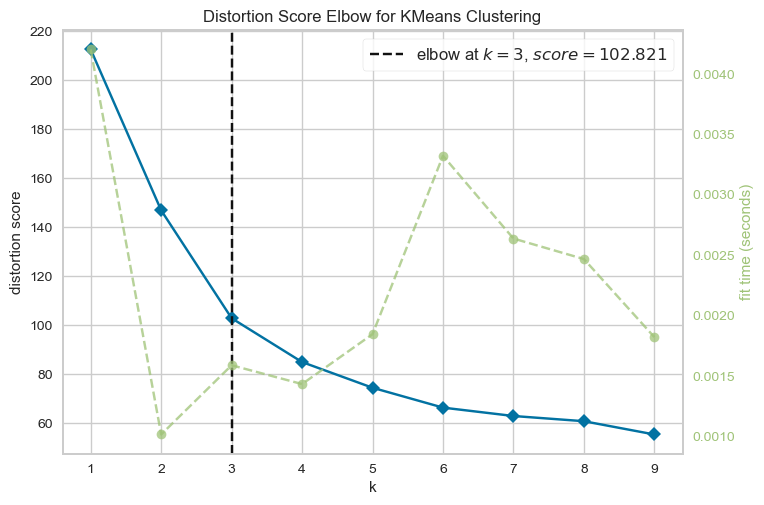

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [584]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

"""
using KMeans!
"""

kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(1, 10), force_model=True)
visualizer.fit(X)
visualizer.show()

In [585]:
X.describe()

,acousticness,danceability,energy,valence,popularity,duration_ms,tempo_cat
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,0.333185,0.580804,0.565832,0.391000,0.622122,0.295897,0.263746
std,0.327171,0.114553,0.191102,0.195829,0.173683,0.086696,0.364673
min,0.000182,0.175000,0.118000,0.038400,0.000000,0.000000,0.000000
25%,0.037325,0.515000,0.418000,0.230000,0.483871,0.242689,0.000000
50%,0.184500,0.593500,0.571000,0.374000,0.666667,0.287255,0.000000
75%,0.660000,0.653000,0.719000,0.522500,0.752688,0.335175,0.500000
max,0.971000,0.897000,0.948000,0.943000,1.000000,1.000000,1.000000


In [586]:
from sklearn.cluster import KMeans

k = 4

kmeans = KMeans(n_clusters=k, random_state=42)
predict = kmeans.fit(X)

labels = kmeans.labels_


def analyze_clusters(X, labels, k):
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]
        print(f"\nCluster {cluster_id + 1}:")
        cluster_means = cluster_data.mean()
        for column_name, mean_value in cluster_means.items():
            print(f"Mean for {column_name}: {mean_value:.2f}")


analyze_clusters(X, labels, k)


Cluster 1:
Mean for acousticness: 0.09
Mean for danceability: 0.58
Mean for energy: 0.69
Mean for valence: 0.46
Mean for popularity: 0.60
Mean for duration_ms: 0.30
Mean for tempo_cat: 0.00

Cluster 2:
Mean for acousticness: 0.70
Mean for danceability: 0.54
Mean for energy: 0.42
Mean for valence: 0.32
Mean for popularity: 0.65
Mean for duration_ms: 0.30
Mean for tempo_cat: 0.75

Cluster 3:
Mean for acousticness: 0.73
Mean for danceability: 0.56
Mean for energy: 0.40
Mean for valence: 0.34
Mean for popularity: 0.64
Mean for duration_ms: 0.29
Mean for tempo_cat: 0.00

Cluster 4:
Mean for acousticness: 0.11
Mean for danceability: 0.62
Mean for energy: 0.61
Mean for valence: 0.37
Mean for popularity: 0.62
Mean for duration_ms: 0.29
Mean for tempo_cat: 0.63


In [587]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.2f}")

Silhouette Score: 0.34


In [588]:
"""
This for plotting and mapping!
"""
df_plot = X.copy()
df_plot['Cluster'] = labels

cluster_means = df_plot.groupby('Cluster').mean()

swiftie_map = {
    0: "midnight drive",  #low acoustic - high energy, fast tempo
    1: "folklore cabin",  #low in all (tempo, acoustic, valence energy)
    2: "red porchlight",  #high acoustic, fast tempo, mid valence, bitter..sweet?
    3: "lavender haze"  #low acoustic, high dance, mid tempo
}

colour_hex_codes = {
    0: ["#1b263b", "#415a77", "#778da9"],
    1: ["#52796f", "#84a98c", "#cad2c5"],
    2: ["#c1121f", "#fdf0d5", "#780000"],
    3: ["#9d4edd", "#c77dff", "#e0aaff"]
}

cluster_songs_map = {}
for i in range(len(cluster_means)):
    cluster_songs_map[i] = {
        "name": swiftie_map.get(i, "Fearless"),
        "hex": colour_hex_codes.get(i, ["#000000"]),
    }


def get_cluster_aura(num):
    return cluster_songs_map.get(num)


""" I originally want to use alpha from feature(s) mean for each colour transparency but I think for now,
distinguishing via different colour based on cluster is enough as MVP!


for i in range(len(cluster_means)):
    feature_alphas = cluster_means.iloc[i].values.flatten().tolist()
    cluster_songs_map[i] = {
        "name": swiftie_map.get(i, "Fearless"),
        "hex": colour_hex_codes.get(i, ["#000000"]),
        "alpha": feature_alphas
    }
"""


' I originally want to use alpha from feature(s) mean for each colour transparency but I think for now,\ndistinguishing via different colour based on cluster is enough as MVP!\n\n\nfor i in range(len(cluster_means)):\n    feature_alphas = cluster_means.iloc[i].values.flatten().tolist()\n    cluster_songs_map[i] = {\n        "name": swiftie_map.get(i, "Fearless"),\n        "hex": colour_hex_codes.get(i, ["#000000"]),\n        "alpha": feature_alphas\n    }\n'

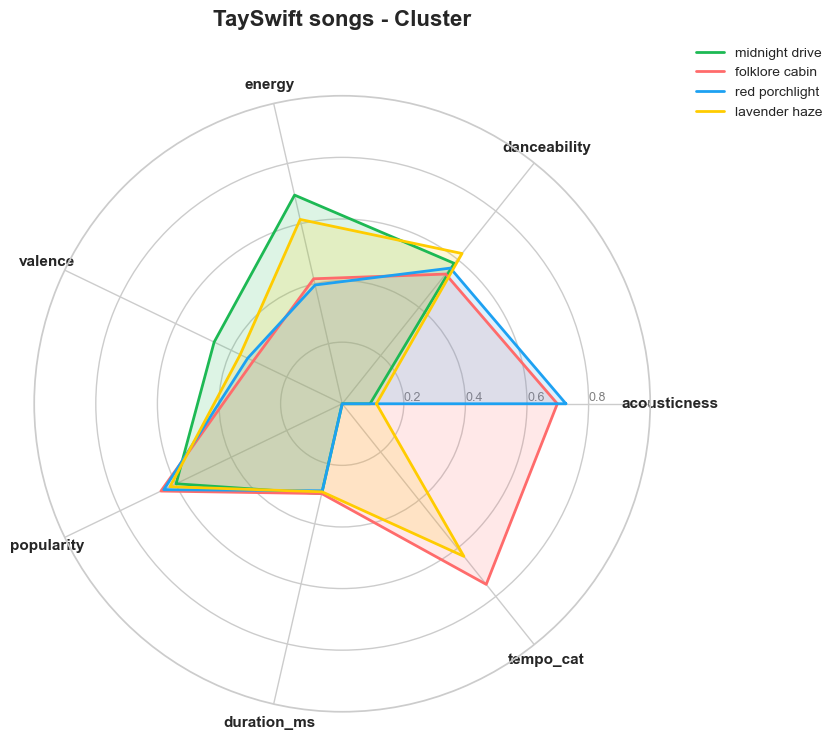

In [589]:
"""
Put spider chart here to show cluster and..MAP it, interpret to humane language!
"""

import matplotlib.pyplot as plt
import numpy as np

categories = cluster_means.columns.tolist()
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

plt.xticks(angles[:-1], categories, size=11, weight='bold')

ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=9)
plt.ylim(0, 1)

colors = ['#1db954', '#ff6b6b', '#1da1f2', '#ffcc00']  # Custom colors for the 4 clusters

for i in range(len(cluster_means)):
    values = cluster_means.iloc[i].values.flatten().tolist()
    values += values[:1]

    era_name = swiftie_map.get(i)

    ax.plot(angles, values, color=colors[i], linewidth=2, linestyle='solid', label=era_name)
    ax.fill(angles, values, color=colors[i], alpha=0.15)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("TaySwift songs - Cluster", size=16, weight='bold', y=1.1)

plt.show()


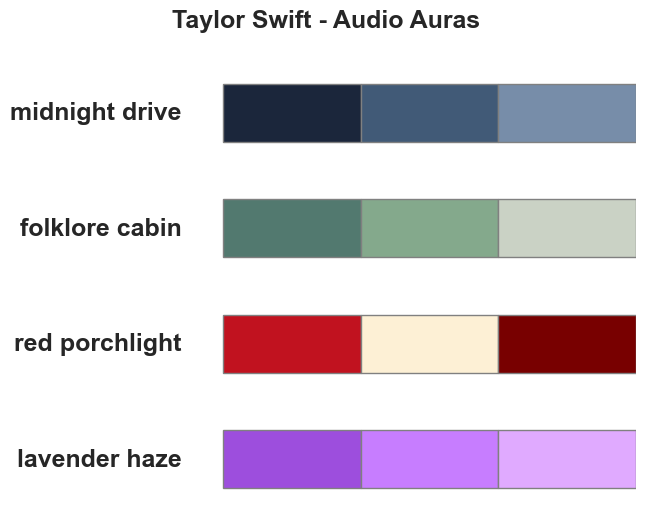

In [590]:
from matplotlib import patches

"""
show colour spectrum!
"""
fig, ax = plt.subplots(figsize=(8, 6))
count_cluster = len(cluster_means)

for cluster_id in range(count_cluster):
    colors = colour_hex_codes[cluster_id]
    era_name = swiftie_map.get(cluster_id, "cardigan")
    y_center = (count_cluster - 1) - cluster_id

    block_width = 1 / len(colors)

    for i, color in enumerate(colors):
        rect = patches.Rectangle(
            (i * block_width, y_center - 0.25),
            block_width,
            0.5,
            color=color,
            ec='grey',
            lw=1
        )
        ax.add_patch(rect)

    ax.text(-0.1, y_center, era_name, va='center', ha='right', fontsize=18, weight='bold')

ax.set_xlim(-0.5, 1)
ax.set_ylim(-0.5, 3.5)
ax.axis('off')

plt.title("Taylor Swift - Audio Auras", fontsize=18, weight='bold', pad=20)
plt.show()


def show_aura(num, song_name):
    fig, ax = plt.subplots(figsize=(10, 2))

    colors = colour_hex_codes[num]
    era_name = swiftie_map.get(num, "cardigan")

    block_width = 1 / len(colors)
    for i, color in enumerate(colors):
        rect = patches.Rectangle(
            (i * block_width, y_center - 0.25),
            block_width,
            0.5,
            color=color,
            ec='grey',
            lw=1
        )
        ax.add_patch(rect)

    ax.text(-0.1, y_center, era_name, va='center', ha='right', fontsize=18, weight='bold')
    ax.set_xlim(-0.5, 1)
    ax.set_ylim(-0.5, 0.5)
    ax.axis('off')
    
    plt.title(f"Taylor Swift - Audio Aura for {song_name}", fontsize=18, weight='bold', pad=20)
    plt.show()

# Because I use quite old data, about 2 years ago, creds goes X in Kaggle. I want to test it on TaySwift new song! TBH, my current favourite is ruin the friendship

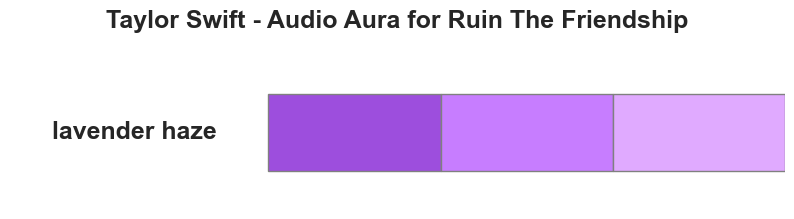

In [591]:
def predict_song_cluster(song_name, features_dict, kmeans_model):
    new_song = pd.DataFrame([features_dict])
    X_new = new_song[['acousticness', 'danceability', 'energy',
                      'valence', 'popularity', 'duration_ms', 'tempo']]
    X_new = scale_data(X_new)
    new_label = kmeans_model.predict(X_new)[0]
    # print(f"'{song_name}' belongs to Cluster {new_label + 1}! {get_cluster_aura(new_label + 1)}")
    show_aura(new_label + 1, song_name)


"""
because I'm currently not in Spotify Premium I can't fetch the API so I asked Qwen 
to generate me a dummy or mock value (just act as a Tarot reader please) for TaySwift's Ruin the Friendship (The Advice Version, which is the acoustic one!) 
"""
ruin_the_friendship_acoustic = {
    'acousticness': 0.89,  # Significant increase for the stripped-back feel
    'danceability': 0.45,  # Lowered as the rhythmic "groove" is replaced by flow
    'energy': 0.28,  # Much lower intensity than the studio version
    'tempo': 112.0,  # Slightly slower, more deliberate pacing
    'valence': 0.35,  # More melancholic/intimate emotional tone
    'popularity': 55,  # Generally lower than the lead studio single
    'duration_ms': 248000  # Often slightly longer due to organic intros/outros
}

predict_song_cluster("Ruin The Friendship", ruin_the_friendship_acoustic, kmeans)

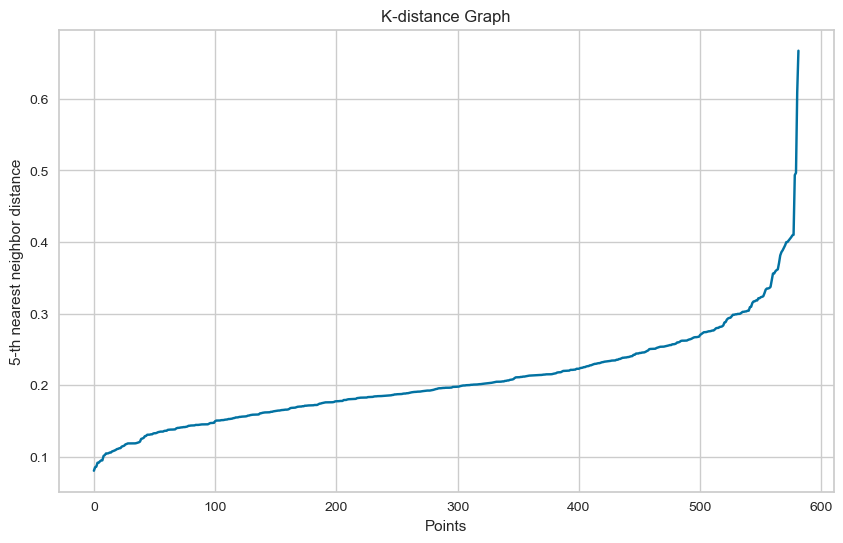

In [592]:
from sklearn.neighbors import NearestNeighbors


def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k - 1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()


plot_k_distance_graph(X, k=5)

In [593]:
from sklearn.cluster import DBSCAN

min_samples = 14  #feature x 2
dbscan = DBSCAN(eps=0.4, min_samples=min_samples)  #epsilon is based on above, we see its 0.4
clusters = dbscan.fit_predict(X)
sil_score = silhouette_score(X, clusters)

print(f"Silhouette Score: {sil_score:.2f}")


Silhouette Score: 0.23


In [594]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 3
Number of noise points: 6


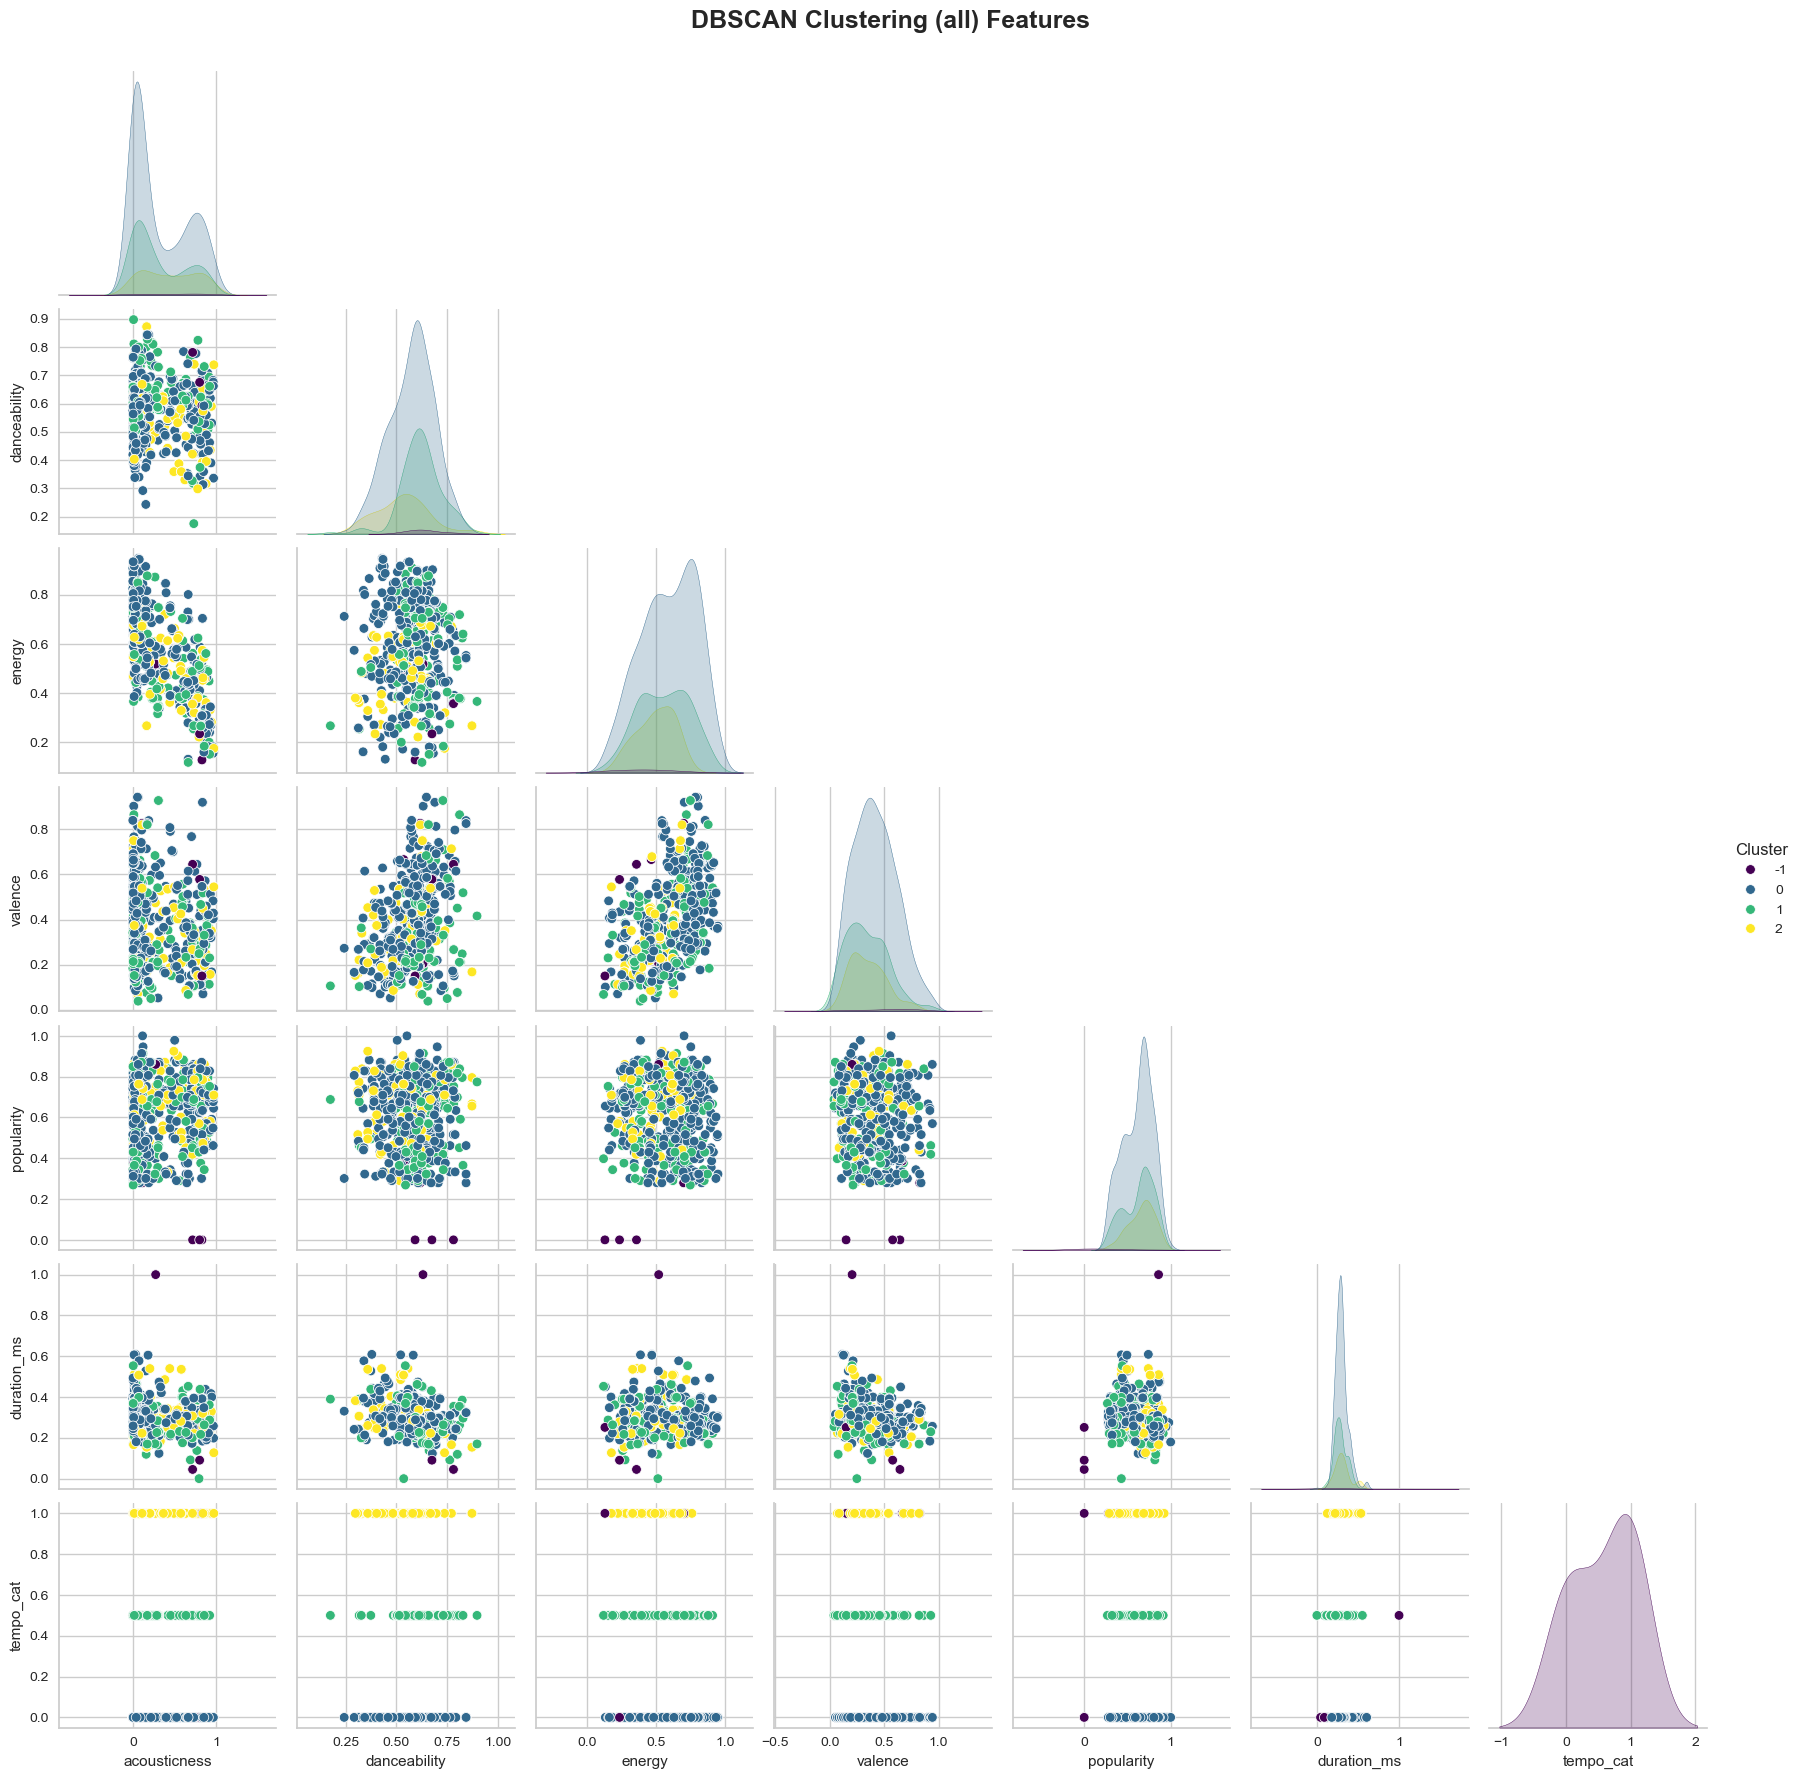

In [595]:
import seaborn as sns
import matplotlib.pyplot as plt

df_dbscan = X.copy()
df_dbscan['Cluster'] = clusters
sns.pairplot(df_dbscan, hue='Cluster', palette='viridis', corner=True)
plt.suptitle('DBSCAN Clustering (all) Features', y=1.02, size=18, weight='bold')
plt.show()